# Grapevine sensitivity analysis

This notebook is a thin wrapper around two standalone scripts:

- **`scripts/run_sensitivity_analysis.py`** -- the data pipeline. Reads raw
  per-simulation CSVs from `HGU-sim/`, reconstructs the missing cane_40/
  cane_50 metadata, applies the treatment filter, summarises each simulation
  to one row, and runs the ANOVA/F-value sensitivity analysis.
- **`scripts/generate_figures.py`** -- plotting only. Reads the CSVs the
  pipeline script produces and draws Figures

Run this notebook top to bottom to regenerate everything from raw data, or
skip the pipeline cell if `outdir/spur` and `outdir/cane` are already
populated (e.g. from a previous run, or checked into the repo) and just
re-run the figure cells.


In [1]:
import sys
from pathlib import Path

from IPython.display import Image, display

%matplotlib inline

REPO_ROOT = Path.cwd().resolve().parents[2]
SCRIPTS_DIR = REPO_ROOT / "scripts"
assert SCRIPTS_DIR.is_dir(), (
    f"Expected scripts/ at {SCRIPTS_DIR} -- edit SCRIPTS_DIR above if your layout differs"
)
sys.path.insert(0, str(SCRIPTS_DIR))

import run_sensitivity_analysis as rsa
import generate_figures as gf

print(f"Loaded pipeline + figure modules from {SCRIPTS_DIR}")

Loaded pipeline + figure modules from /powerplant/workspace/hrayzl/grapevine-indoor-optimisation/scripts


## 1. Run the data pipeline (spur + cane)

Writes the three CSVs `generate_figures.py` reads back in, under `outdir/spur/` and `outdir/cane/` (relative to this notebook's own folder).

In [2]:
# Output location for the processed CSVs and figures, relative to this notebook's own folder
OUTDIR = "outdir"

rsa.main(["--vine-type", "spur", "--outdir", f"{OUTDIR}/spur"])
rsa.main(["--vine-type", "cane", "--outdir", f"{OUTDIR}/cane"])

Using config: /powerplant/workspace/hrayzl/grapevine-indoor-optimisation/config.json
Loading raw simulation data for vine_type='spur' from /output/FruitCropXL/HGU-sim/ ...
spur: 943 simulations retained after filtering/summarising
Crop-load levels present: [50.0, 70.0, 90.0, 110.0]
Done. Wrote daily_timeseries_with_treatment.csv, per_simulation_df_with_treatment.csv, and f_values_sensitivity_analysis_results_with_inputs.csv to outdir/spur/
Using config: /powerplant/workspace/hrayzl/grapevine-indoor-optimisation/config.json
Loading raw simulation data for vine_type='cane' from /output/FruitCropXL/HGU-sim/ ...
cane: 946 simulations retained after filtering/summarising
Crop-load levels present: [160.0, 240.0, 320.0, 400.0]
Done. Wrote daily_timeseries_with_treatment.csv, per_simulation_df_with_treatment.csv, and f_values_sensitivity_analysis_results_with_inputs.csv to outdir/cane/


## 2. Load the computed results

In [3]:
spur_anova, cane_anova, spur_summary, cane_summary, all_summary, all_daily = gf.load_data(OUTDIR)

## Figure 6 -- Harvest-index sensitivity

A panel-by-panel walkthrough (canopy renders, the η²ₚ driver-ranking bar chart, the four leaf-number response curves), plus what the shaded bands actually represent (spread across CO₂/radiation/temperature combos, not uncertainty in the mean).

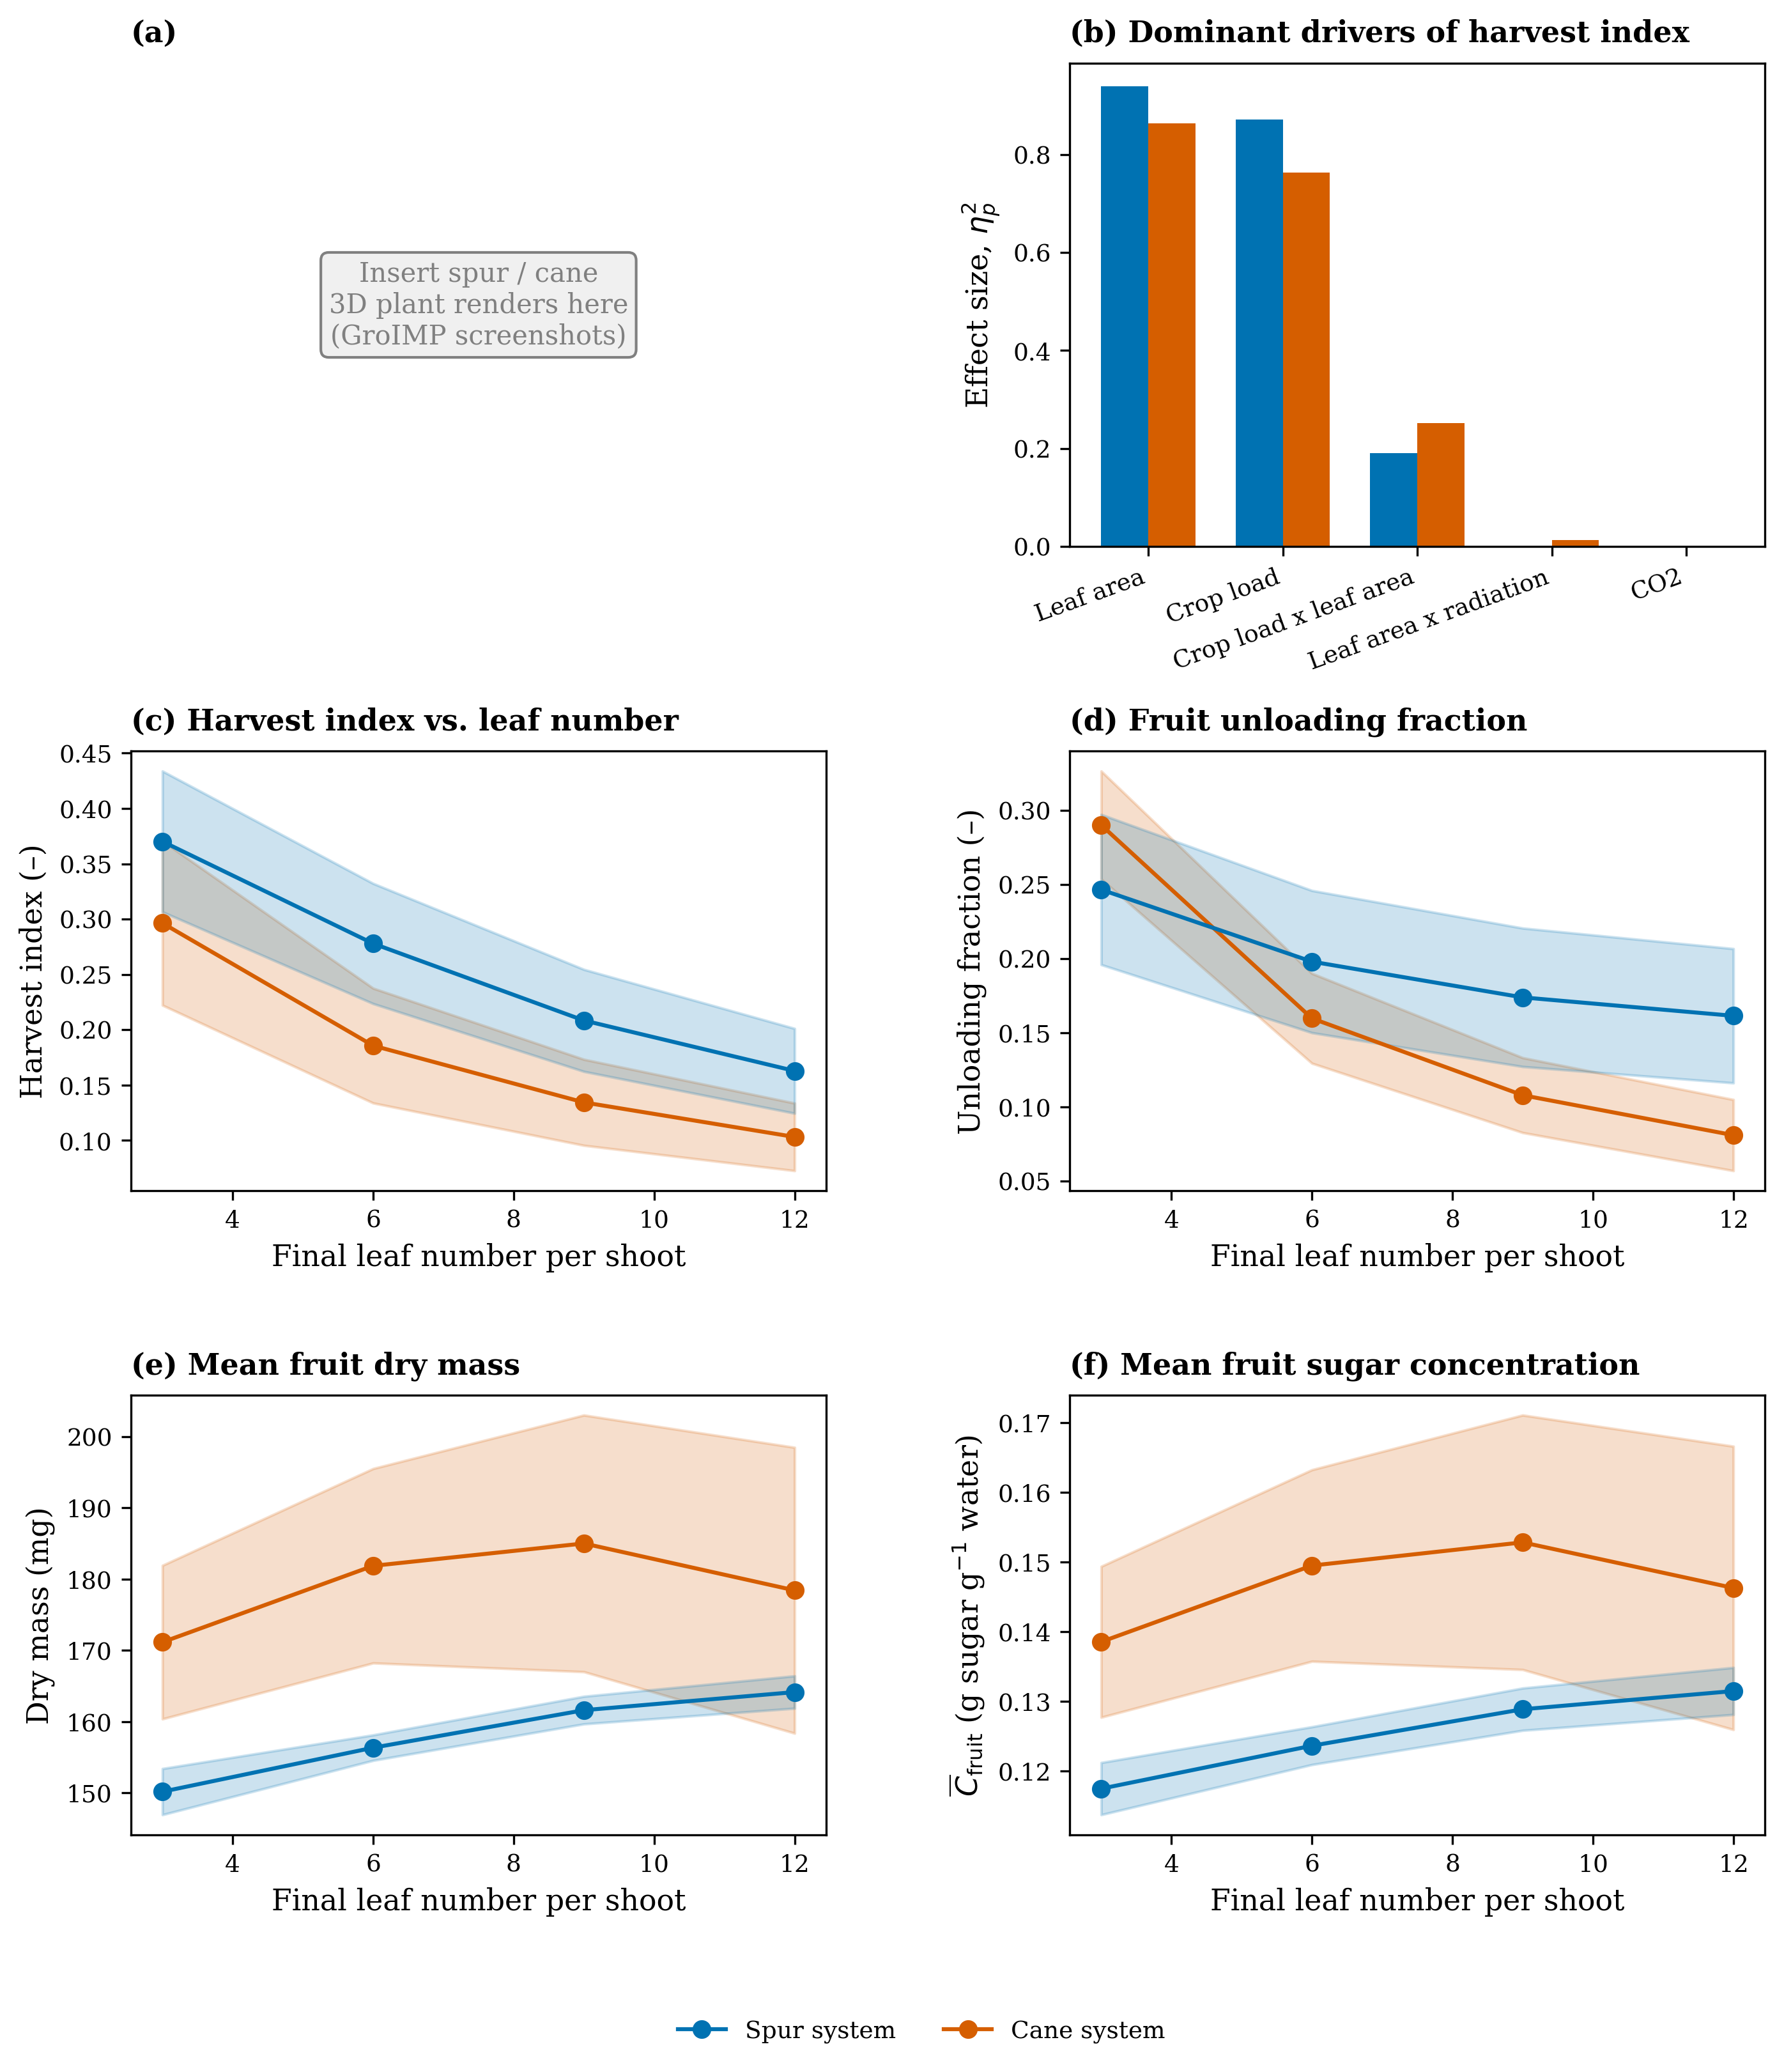

In [4]:
gf.make_figure6(spur_anova, cane_anova, all_summary, outdir=OUTDIR)
display(Image(f"{OUTDIR}/Figure6.png"))

## Supplementary Figure S1 -- broader sensitivity analysis

It explains the 4×2 grid (output × training system) and how to scan it both ways, down a column for what matters within a system, across a row for spur-vs-cane comparison.

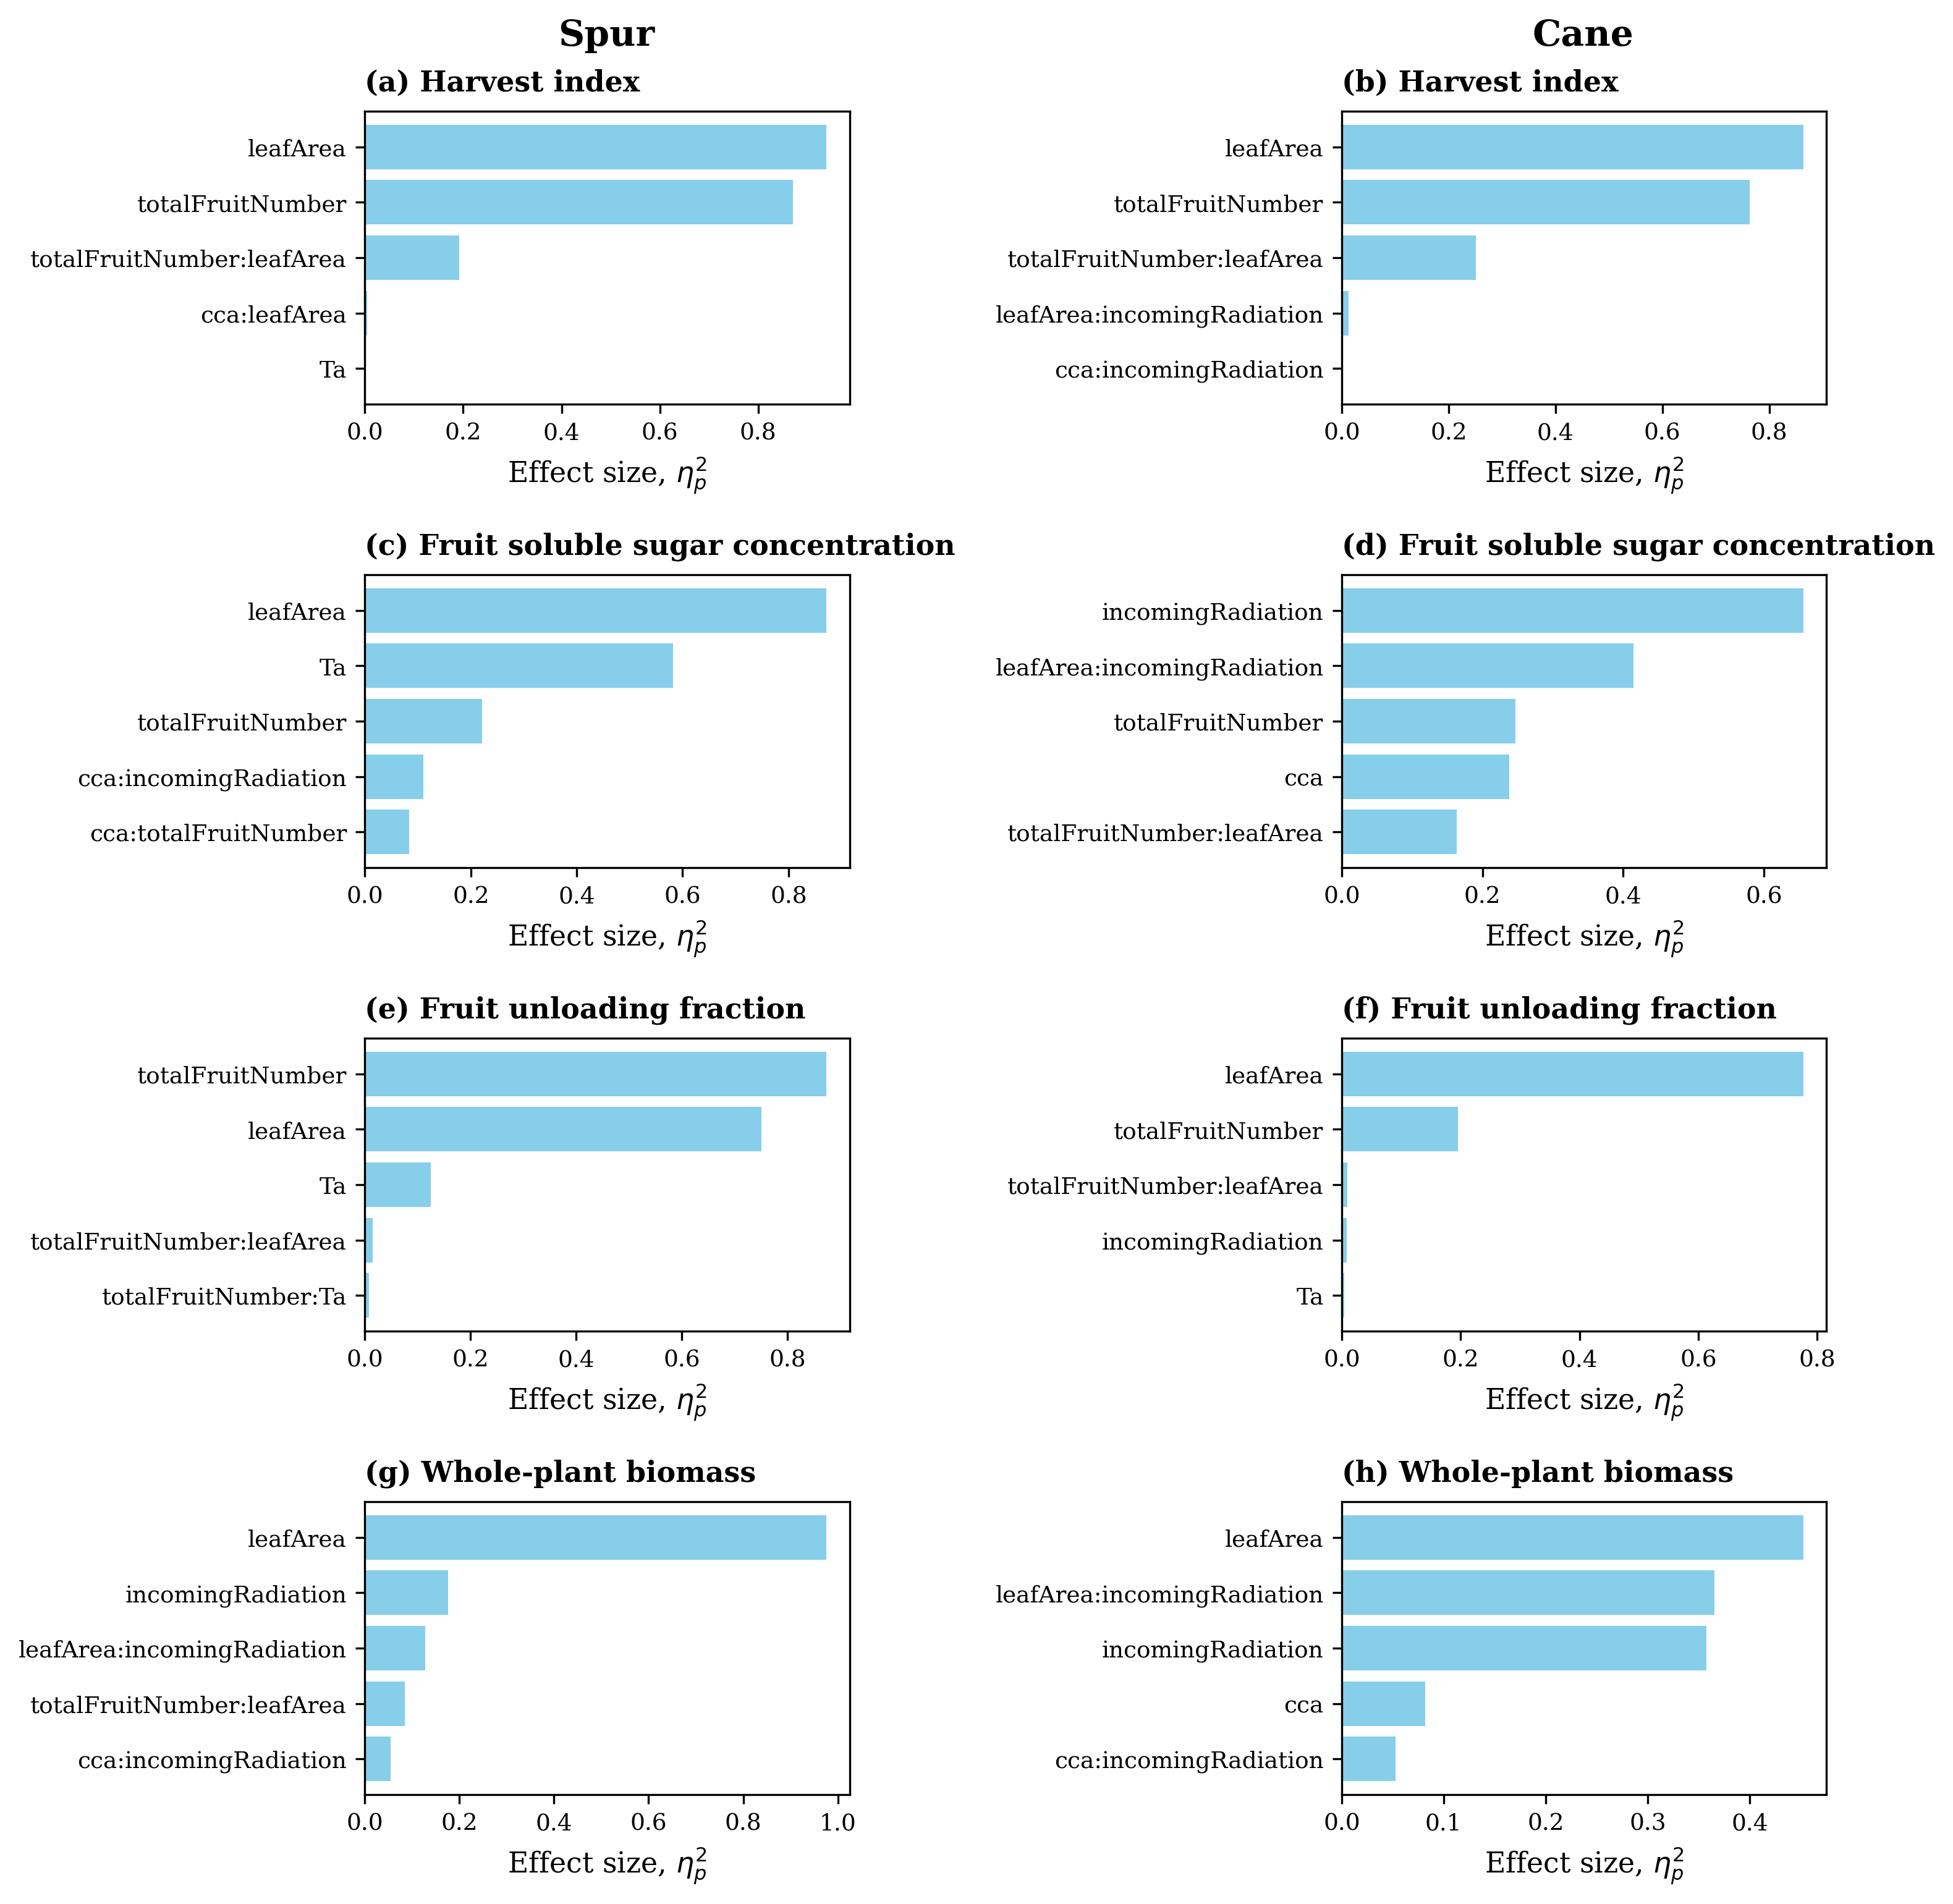

In [5]:
gf.make_figureS1(spur_anova, cane_anova, outdir=OUTDIR)
display(Image(f"{OUTDIR}/FigureS1.png"))

## Supplementary Figure S2 -- seasonal source-sink dynamics

Frames it against Figure 6/S1 in the trajectory view, so the line is specifically about whether differences are fixed early or accumulate over the season.

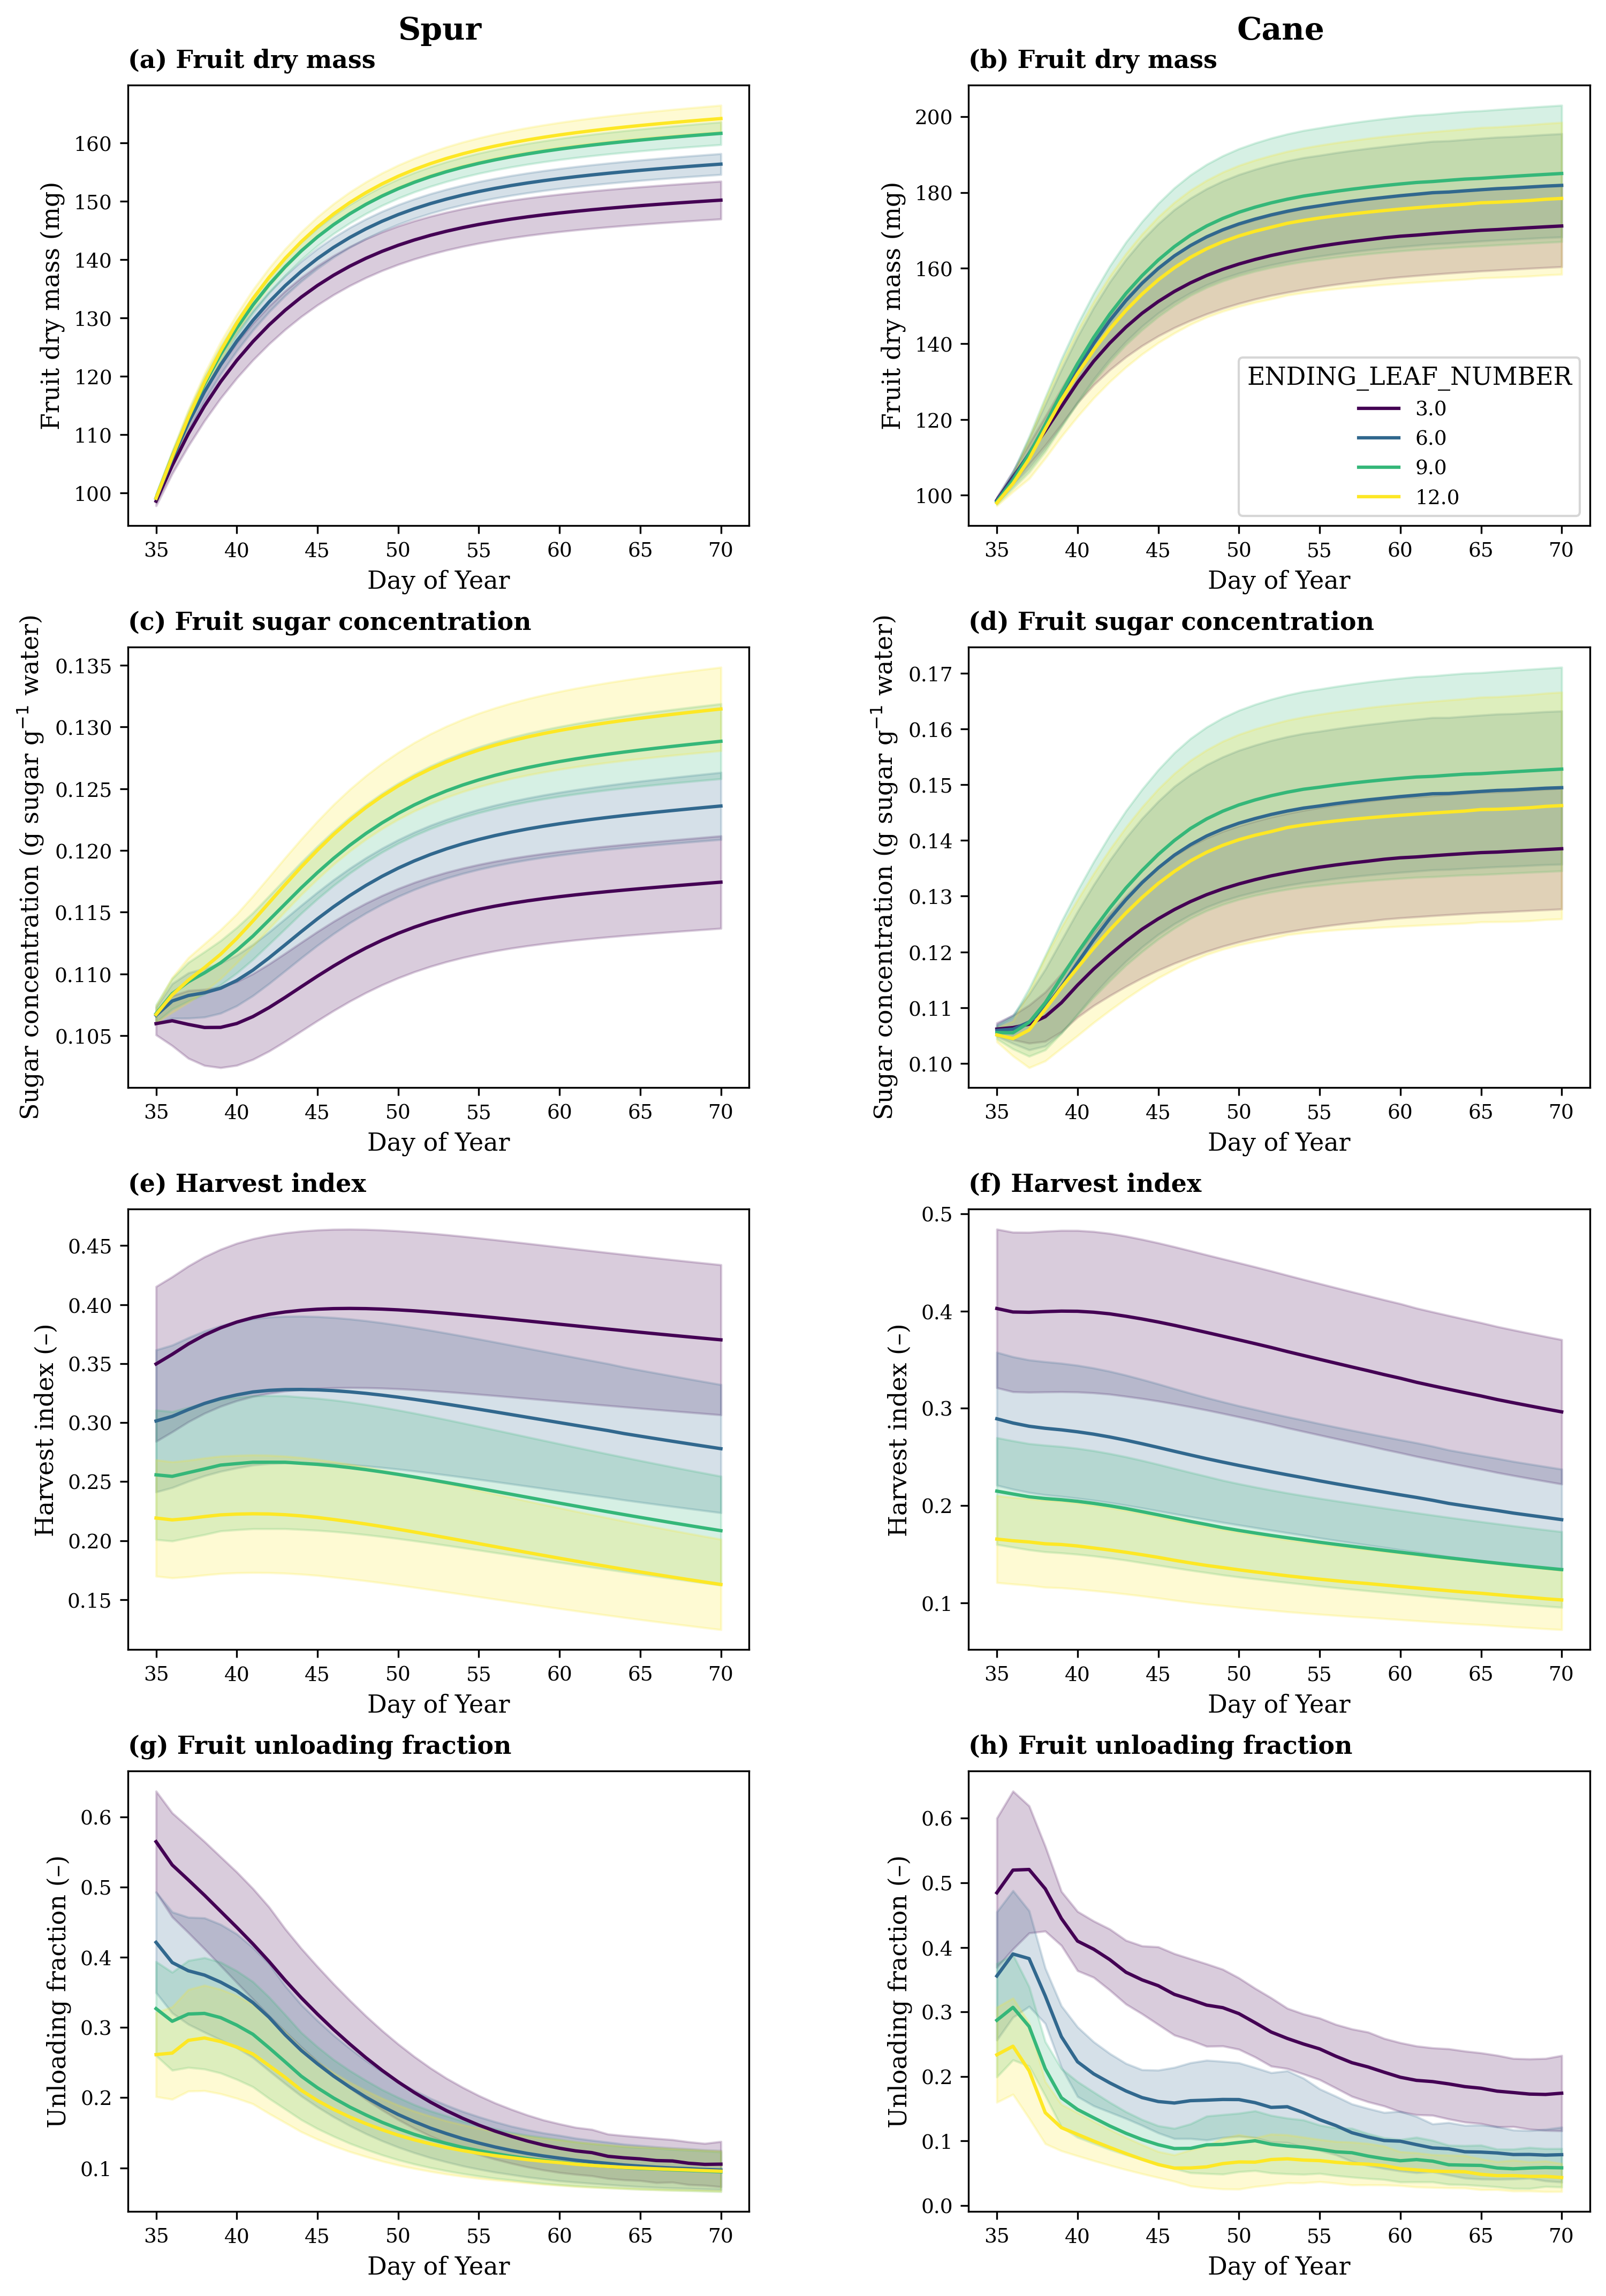

In [6]:
gf.make_figureS2(all_daily, outdir=OUTDIR)
display(Image(f"{OUTDIR}/FigureS2.png"))

## Supplementary Figure S3 -- leaf number x crop-load response surface

It ties back explicitly to the S1 interaction term (totalFruitNumber:leafArea), explaining how a diagonal color gradient in the heatmap is the visual signature of that interaction.

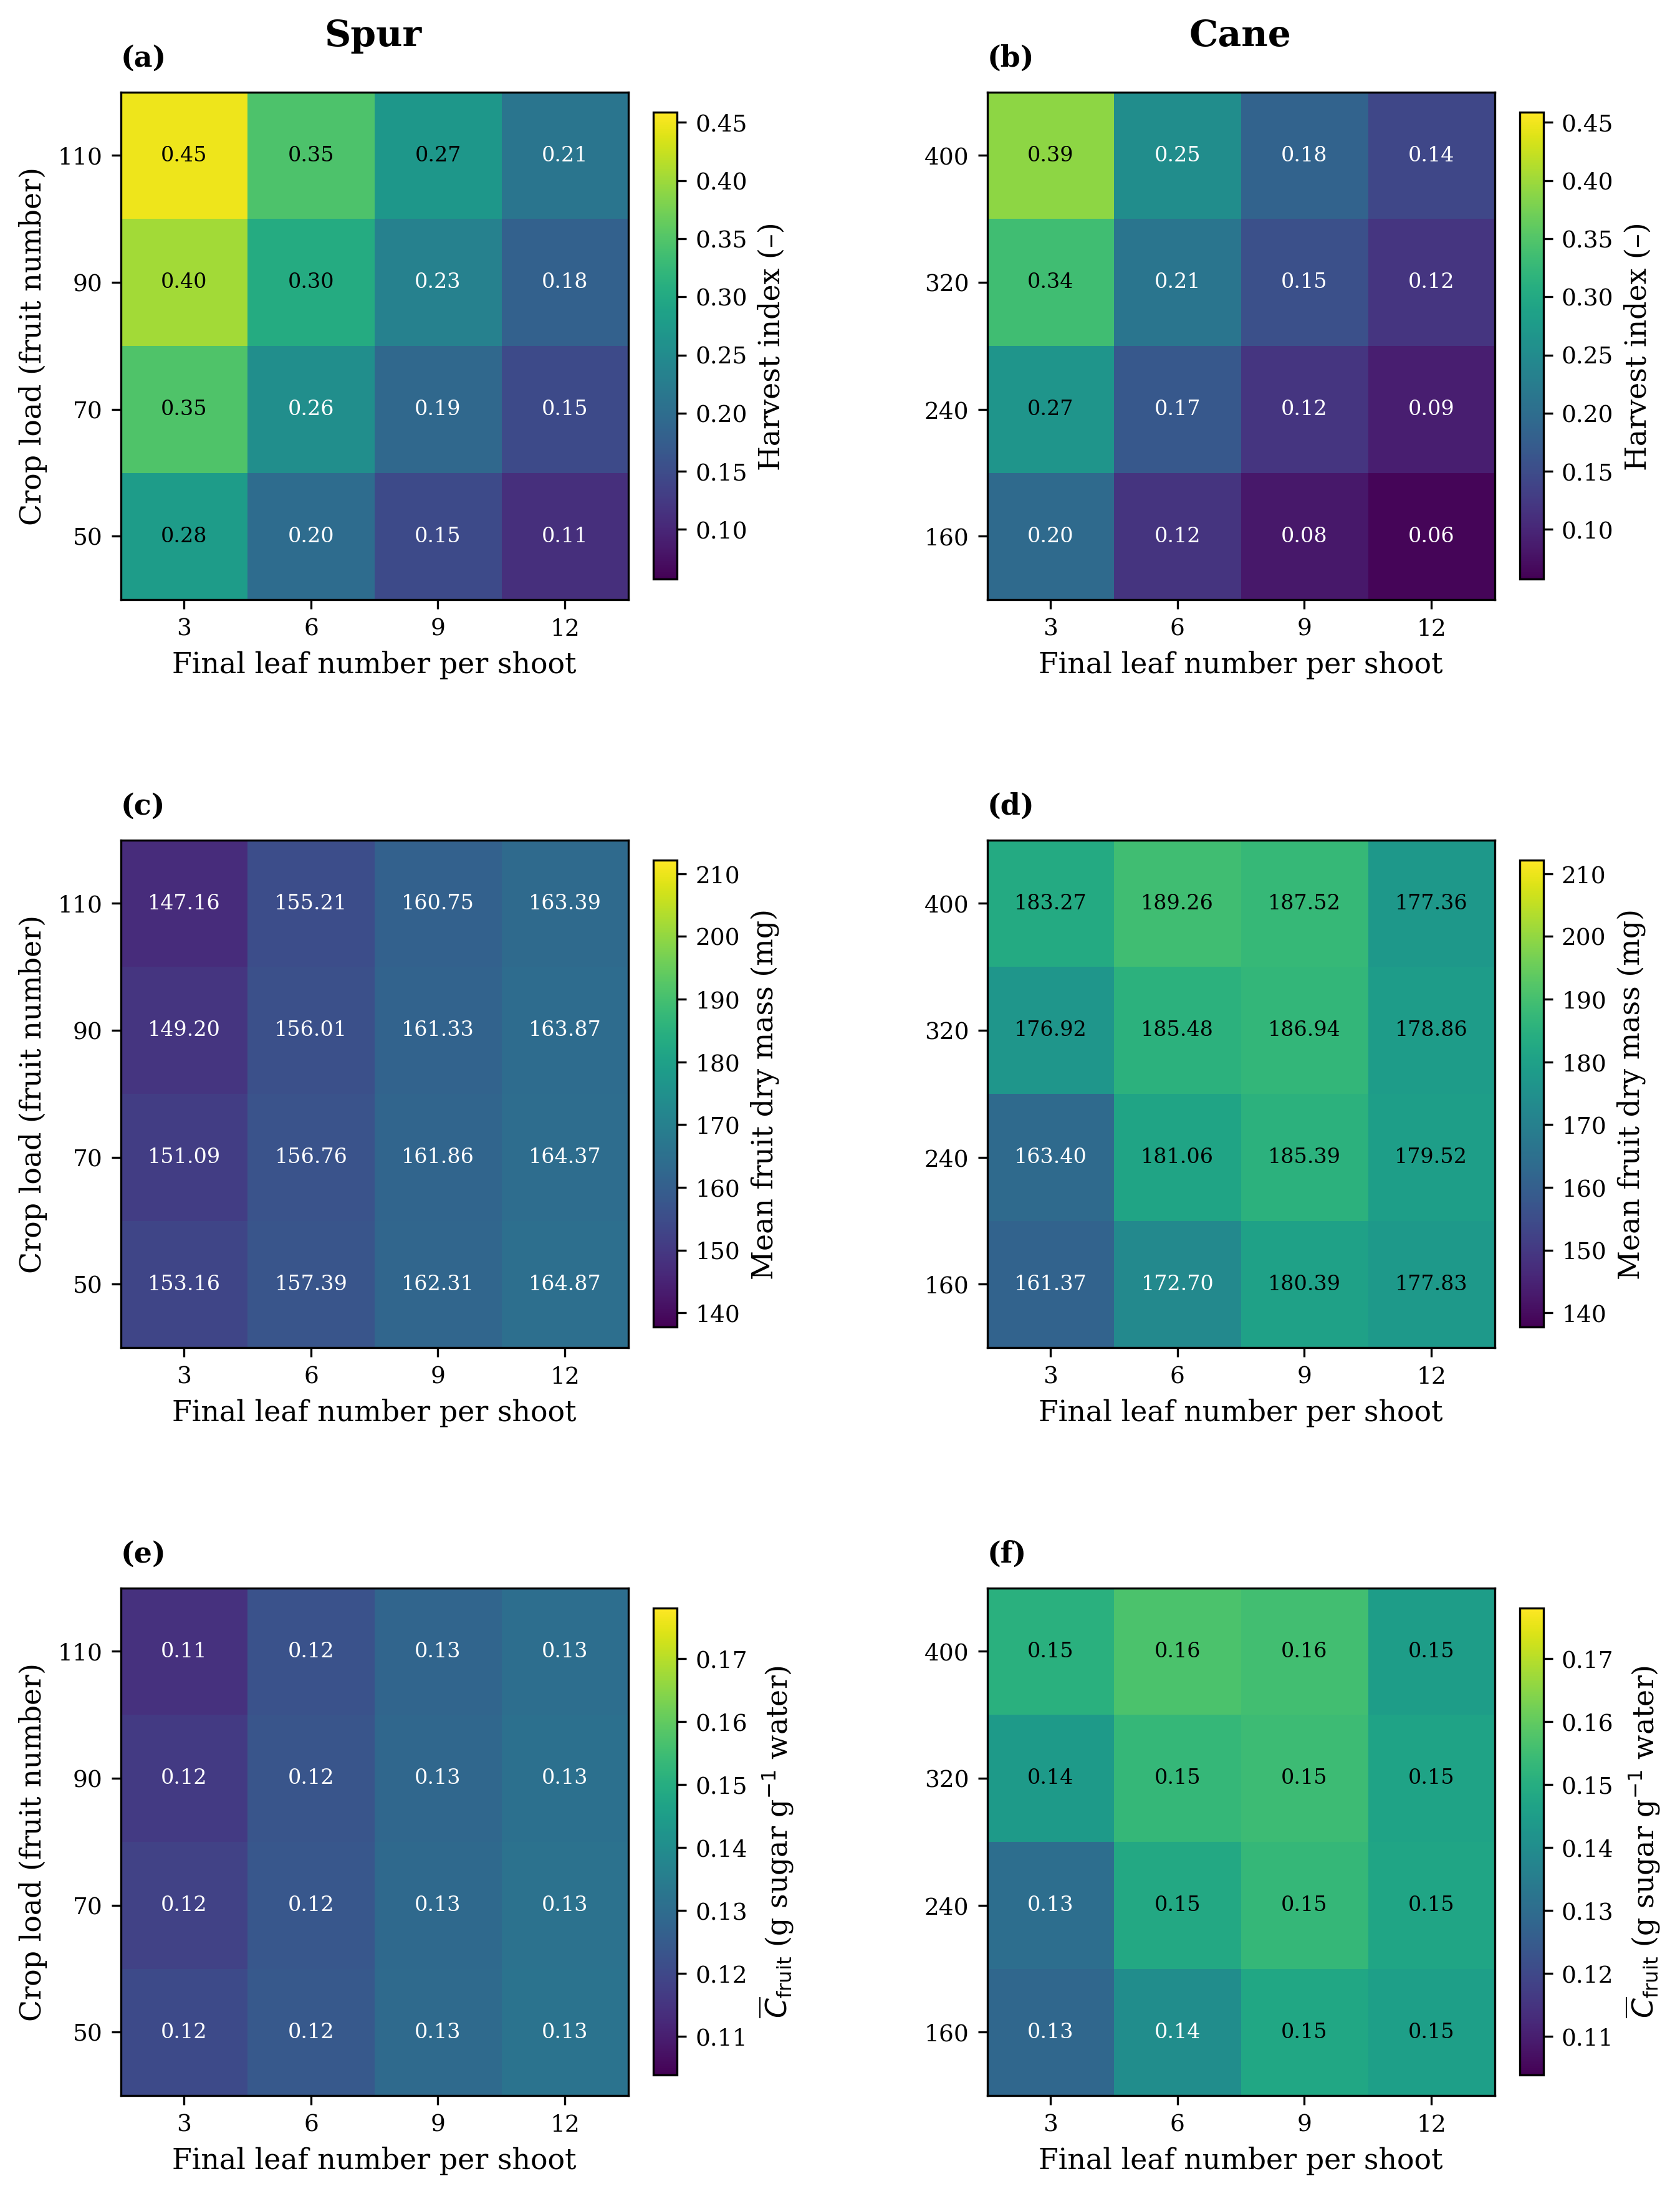

In [7]:
gf.make_figureS3(spur_summary, cane_summary, outdir=OUTDIR)
display(Image(f"{OUTDIR}/FigureS3.png"))